# 03 — Spatial Binning & Cell-Day Fire Panel (Kalimantan Development)

**Purpose:** build and validate the spatial fire panel for the current development/testing phase.

> **Development scope:** Kalimantan only.  
> Sumatra will be integrated after the pipeline is stable.

## Objectives
1. Load all available Kalimantan FIRMS fire files.
2. Inspect file coverage and schema.
3. Assign each FIRMS detection to the nearest AQ/grid cell.
4. Aggregate detections into `cell-day`.
5. Create a complete cell × date panel.
6. Define `fire_active` and next-day target `target_fire_active_t1`.
7. Validate duplicates, missing dates, spatial assignment, and temporal ordering.
8. Save clean intermediate outputs for Notebook 04.

### Important label interpretation
`fire_active = 1` means the cell-day contains observed FIRMS fire detections according to the project's activity definition.  
`fire_active = 0` means no FIRMS detection was observed in that cell-day; it should **not** be interpreted as proof that no fire existed.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

# Project root = one level above notebooks/
PROJECT_ROOT = Path.cwd().parent

FIRE_DIR = PROJECT_ROOT / "data" / "raw" / "kalimantan" / "fire_firms" / "hourly"
AQ_DIR = PROJECT_ROOT / "data" / "raw" / "kalimantan" / "air_quality_openmeteo" / "hourly"

INTERMEDIATE_DIR = PROJECT_ROOT / "data" / "intermediate"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Fire dir     :", FIRE_DIR)
print("AQ dir       :", AQ_DIR)
print("Fire exists  :", FIRE_DIR.exists())
print("AQ exists    :", AQ_DIR.exists())


Project root : c:\Users\Asus\Documents\skripsi-karhut
Fire dir     : c:\Users\Asus\Documents\skripsi-karhut\data\raw\kalimantan\fire_firms\hourly
AQ dir       : c:\Users\Asus\Documents\skripsi-karhut\data\raw\kalimantan\air_quality_openmeteo\hourly
Fire exists  : True
AQ exists    : True


## 1. Inspect input files

The main pipeline uses **all available FIRMS daily/hourly CSV files**, not a single sample date.


In [2]:
fire_files = sorted(FIRE_DIR.glob("*.csv"))

print(f"Number of FIRMS files: {len(fire_files)}")

if fire_files:
    print("First file :", fire_files[0].name)
    print("Last file  :", fire_files[-1].name)
    print("Date-like filenames:")
    print([f.name for f in fire_files[:5]])
    print("...")
    print([f.name for f in fire_files[-5:]])
else:
    raise FileNotFoundError(f"No CSV files found in {FIRE_DIR}")


Number of FIRMS files: 134
First file : fires_2026-05-01.csv
Last file  : fires_2026-09-11.csv
Date-like filenames:
['fires_2026-05-01.csv', 'fires_2026-05-02.csv', 'fires_2026-05-03.csv', 'fires_2026-05-04.csv', 'fires_2026-05-05.csv']
...
['fires_2026-09-07.csv', 'fires_2026-09-08.csv', 'fires_2026-09-09.csv', 'fires_2026-09-10.csv', 'fires_2026-09-11.csv']


In [3]:
# Check filename date continuity where filenames follow fires_YYYY-MM-DD.csv
filename_dates = pd.to_datetime(
    [f.stem.replace("fires_", "") for f in fire_files],
    errors="coerce"
)

file_audit = pd.DataFrame({
    "file": [f.name for f in fire_files],
    "date": filename_dates
})

print("Unparseable filename dates:", file_audit["date"].isna().sum())

if file_audit["date"].notna().all():
    file_audit = file_audit.sort_values("date").reset_index(drop=True)
    expected_dates = pd.date_range(
        file_audit["date"].min(),
        file_audit["date"].max(),
        freq="D"
    )
    missing_dates = expected_dates.difference(file_audit["date"])

    print("Filename date range:",
          file_audit["date"].min().date(),
          "→",
          file_audit["date"].max().date())
    print("Expected daily files:", len(expected_dates))
    print("Actual files       :", len(file_audit))
    print("Missing filename dates:", len(missing_dates))

    if len(missing_dates) > 0:
        print(missing_dates.tolist())


Unparseable filename dates: 0
Filename date range: 2026-05-01 → 2026-09-11
Expected daily files: 134
Actual files       : 134
Missing filename dates: 0


## 2. Inspect one FIRMS file

This is only a schema/quality check. The modeling dataset is built from **all files** below.


In [4]:
sample_fire_file = fire_files[0]
sample_fire = pd.read_csv(sample_fire_file)

print("Sample file:", sample_fire_file.name)
print("Shape:", sample_fire.shape)
print("Columns:", sample_fire.columns.tolist())

display(sample_fire.head())
sample_fire.info()


Sample file: fires_2026-05-01.csv
Shape: (77, 4)
Columns: ['time_utc', 'lat', 'lon', 'frp']


,time_utc,lat,lon,frp
0,2026-05-01T06:00,-0.24059,116.94825,4.15
1,2026-05-01T06:00,-0.10568,117.44133,4.40
2,2026-05-01T06:00,-0.10557,117.44176,4.07
3,2026-05-01T06:00,-0.05591,117.27164,5.60
4,2026-05-01T06:00,0.59490,116.66753,4.49


<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time_utc  77 non-null     str    
 1   lat       77 non-null     float64
 2   lon       77 non-null     float64
 3   frp       77 non-null     float64
dtypes: float64(3), str(1)
memory usage: 3.7 KB


In [5]:
required_fire_cols = {"time_utc", "lat", "lon", "frp"}

missing_fire_cols = required_fire_cols - set(sample_fire.columns)

if missing_fire_cols:
    raise ValueError(f"Missing required FIRMS columns: {missing_fire_cols}")

print("Required FIRMS columns are present.")


Required FIRMS columns are present.


## 3. Load all FIRMS detections

Each file is loaded independently so the audit can identify empty files or malformed files before concatenation.


In [6]:
all_fire_parts = []
fire_file_audit = []

for i, file in enumerate(fire_files, start=1):
    try:
        df = pd.read_csv(file)

        row_count = len(df)

        fire_file_audit.append({
            "file": file.name,
            "rows": row_count,
            "status": "OK"
        })

        if row_count > 0:
            all_fire_parts.append(df)

    except Exception as e:
        fire_file_audit.append({
            "file": file.name,
            "rows": np.nan,
            "status": f"ERROR: {e}"
        })

fire_file_audit = pd.DataFrame(fire_file_audit)

print("Files processed:", len(fire_file_audit))
print("Non-empty files:", (fire_file_audit["rows"].fillna(0) > 0).sum())
print("Empty files    :", (fire_file_audit["rows"].fillna(0) == 0).sum())
print("Errors         :", fire_file_audit["status"].astype(str).str.startswith("ERROR").sum())

display(fire_file_audit.head())


Files processed: 134
Non-empty files: 126
Empty files    : 8
Errors         : 0


,file,rows,status
0,fires_2026-05-01.csv,77,OK
1,fires_2026-05-02.csv,136,OK
2,fires_2026-05-03.csv,112,OK
3,fires_2026-05-04.csv,69,OK
4,fires_2026-05-05.csv,69,OK


In [7]:
if fire_file_audit["status"].astype(str).str.startswith("ERROR").any():
    display(fire_file_audit[
        fire_file_audit["status"].astype(str).str.startswith("ERROR")
    ])
    raise RuntimeError("One or more FIRMS files could not be loaded.")

fire = pd.concat(all_fire_parts, ignore_index=True)

print("Combined FIRMS shape:", fire.shape)
display(fire.head())


Combined FIRMS shape: (146314, 4)


,time_utc,lat,lon,frp
0,2026-05-01T06:00,-0.24059,116.94825,4.15
1,2026-05-01T06:00,-0.10568,117.44133,4.40
2,2026-05-01T06:00,-0.10557,117.44176,4.07
3,2026-05-01T06:00,-0.05591,117.27164,5.60
4,2026-05-01T06:00,0.59490,116.66753,4.49


## 4. Clean and validate FIRMS data

The cleaning here is conservative:
- parse timestamp;
- convert coordinates and FRP to numeric;
- remove rows missing the fields required for spatial binning/FRP aggregation;
- remove exact duplicate records if present.


In [8]:
fire["time_utc"] = pd.to_datetime(
    fire["time_utc"],
    errors="coerce"
)

for col in ["lat", "lon", "frp"]:
    fire[col] = pd.to_numeric(fire[col], errors="coerce")

before_clean = len(fire)

required_values = ["time_utc", "lat", "lon", "frp"]
fire = fire.dropna(subset=required_values).copy()

after_required_drop = len(fire)

exact_duplicates = fire.duplicated().sum()
fire = fire.drop_duplicates().copy()

print("Rows before cleaning      :", before_clean)
print("Dropped missing required  :", before_clean - after_required_drop)
print("Exact duplicate rows      :", exact_duplicates)
print("Rows after cleaning       :", len(fire))


Rows before cleaning      : 146314
Dropped missing required  : 0
Exact duplicate rows      : 0
Rows after cleaning       : 146314


In [9]:
print("Time range:")
print(fire["time_utc"].min(), "→", fire["time_utc"].max())

print("\nLatitude range:")
print(fire["lat"].min(), "→", fire["lat"].max())

print("\nLongitude range:")
print(fire["lon"].min(), "→", fire["lon"].max())

print("\nFRP summary:")
display(fire["frp"].describe())


Time range:
2026-05-01 06:00:00 → 2026-09-11 06:00:00

Latitude range:
-4.26212 → 7.38579

Longitude range:
108.00037 → 119.49989

FRP summary:


count    146314.000000
mean          8.134530
std          13.258144
min           0.140000
25%           2.140000
50%           4.520000
75%           8.750000
max         569.390000
Name: frp, dtype: float64

## 5. Visualize raw FIRMS detections

This visualization is for a sanity check before binning.


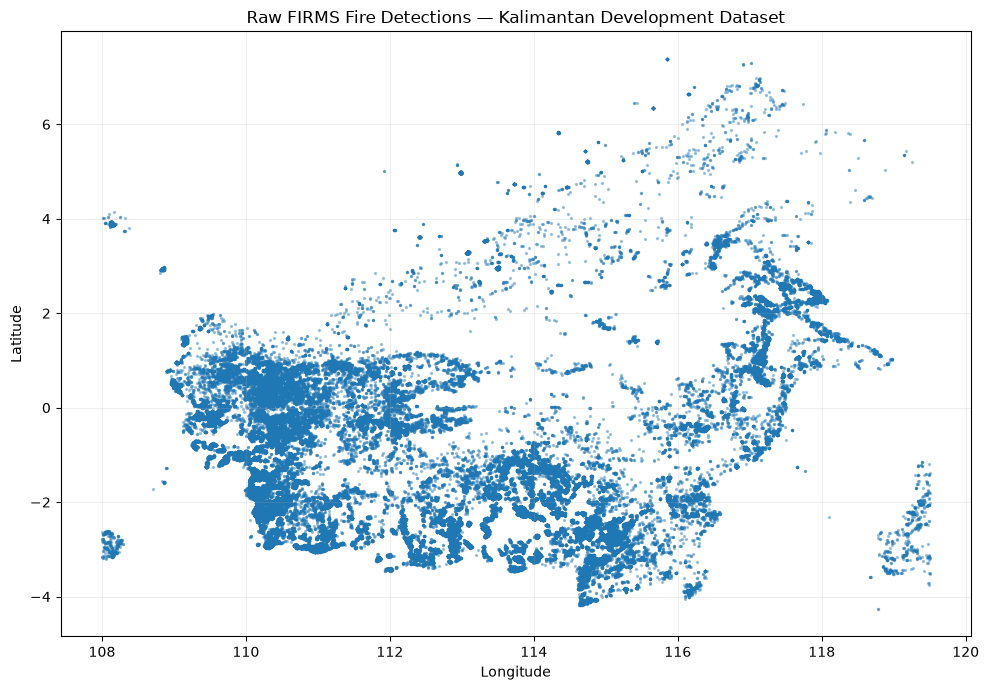

In [10]:
plt.figure(figsize=(10, 7))

plt.scatter(
    fire["lon"],
    fire["lat"],
    s=2,
    alpha=0.35
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Raw FIRMS Fire Detections — Kalimantan Development Dataset")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 6. Load the Kalimantan grid

The current project uses the available AQ grid as the spatial reference grid for the fire observations.


In [11]:
aq_files = sorted(AQ_DIR.glob("*.csv"))

print("AQ files:", len(aq_files))

if not aq_files:
    raise FileNotFoundError(f"No AQ CSV files found in {AQ_DIR}")

# Use one AQ file only to obtain the static spatial grid.
# The AQ values themselves are handled in Notebook 04.
aq_sample_file = aq_files[0]
aq_sample = pd.read_csv(aq_sample_file)

print("AQ sample file:", aq_sample_file.name)
print("Shape:", aq_sample.shape)
print("Columns:", aq_sample.columns.tolist())

display(aq_sample.head())


AQ files: 1
AQ sample file: pm25_2026-09-07.csv
Shape: (6528, 4)
Columns: ['time_utc', 'lat', 'lon', 'pm2_5']


,time_utc,lat,lon,pm2_5
0,2026-09-07T00:00,-4.5,108.0,14.9
1,2026-09-07T01:00,-4.5,108.0,16.6
2,2026-09-07T02:00,-4.5,108.0,18.0
3,2026-09-07T03:00,-4.5,108.0,19.1
4,2026-09-07T04:00,-4.5,108.0,20.5


In [12]:
required_aq_coord_cols = {"lat", "lon"}

missing_aq_coord_cols = required_aq_coord_cols - set(aq_sample.columns)

if missing_aq_coord_cols:
    raise ValueError(
        f"Missing AQ coordinate columns: {missing_aq_coord_cols}"
    )

grid = (
    aq_sample[["lat", "lon"]]
    .drop_duplicates()
    .sort_values(["lat", "lon"])
    .reset_index(drop=True)
    .rename(columns={
        "lat": "grid_lat",
        "lon": "grid_lon"
    })
)

print("Number of grid cells:", len(grid))
print("Unique latitudes   :", grid["grid_lat"].nunique())
print("Unique longitudes  :", grid["grid_lon"].nunique())

display(grid.head(20))


Number of grid cells: 272
Unique latitudes   : 17
Unique longitudes  : 16


,grid_lat,grid_lon
0,-4.50,108.00
1,-4.50,108.75
2,-4.50,109.50
3,-4.50,110.25
4,-4.50,111.00
5,-4.50,111.75
6,-4.50,112.50
7,-4.50,113.25
8,-4.50,114.00
9,-4.50,114.75


In [13]:
grid_lats = np.sort(grid["grid_lat"].unique())
grid_lons = np.sort(grid["grid_lon"].unique())

print("Latitude values:")
print(grid_lats)

print("\nLongitude values:")
print(grid_lons)


Latitude values:
[-4.5  -3.75 -3.   -2.25 -1.5  -0.75  0.    0.75  1.5   2.25  3.    3.75
  4.5   5.25  6.    6.75  7.5 ]

Longitude values:
[108.   108.75 109.5  110.25 111.   111.75 112.5  113.25 114.   114.75
 115.5  116.25 117.   117.75 118.5  119.25]


## 7. Assign each FIRMS point to the nearest grid cell

The assignment is based on nearest latitude and nearest longitude on the regular project grid.

The resulting `cell_id` explicitly includes the region name so that the identifier remains safe when Sumatra is integrated later.


In [14]:
def nearest_value(value, candidates):
    idx = np.abs(candidates - value).argmin()
    return candidates[idx]

fire["grid_lat"] = fire["lat"].apply(
    lambda x: nearest_value(x, grid_lats)
)

fire["grid_lon"] = fire["lon"].apply(
    lambda x: nearest_value(x, grid_lons)
)

fire["region"] = "Kalimantan"

fire["cell_id"] = (
    fire["region"]
    + "_"
    + fire["grid_lat"].map(lambda x: f"{x:.2f}")
    + "_"
    + fire["grid_lon"].map(lambda x: f"{x:.2f}")
)

display(
    fire[
        ["time_utc", "lat", "lon", "grid_lat", "grid_lon", "cell_id", "frp"]
    ].head(10)
)


,time_utc,lat,lon,grid_lat,grid_lon,cell_id,frp
0,2026-05-01 06:00:00,-0.24059,116.94825,0.00,117.00,Kalimantan_0.00_117.00,4.15
1,2026-05-01 06:00:00,-0.10568,117.44133,0.00,117.75,Kalimantan_0.00_117.75,4.40
2,2026-05-01 06:00:00,-0.10557,117.44176,0.00,117.75,Kalimantan_0.00_117.75,4.07
3,2026-05-01 06:00:00,-0.05591,117.27164,0.00,117.00,Kalimantan_0.00_117.00,5.60
4,2026-05-01 06:00:00,0.59490,116.66753,0.75,117.00,Kalimantan_0.75_117.00,4.49
5,2026-05-01 06:00:00,0.77395,116.82831,0.75,117.00,Kalimantan_0.75_117.00,3.49
6,2026-05-01 06:00:00,0.78220,116.91245,0.75,117.00,Kalimantan_0.75_117.00,2.69
7,2026-05-01 06:00:00,0.78649,116.91179,0.75,117.00,Kalimantan_0.75_117.00,3.08
8,2026-05-01 06:00:00,1.21444,117.95267,1.50,117.75,Kalimantan_1.50_117.75,3.99
9,2026-05-01 06:00:00,1.33860,116.65590,1.50,117.00,Kalimantan_1.50_117.00,8.79


### Spatial assignment distance check

Because nearest-grid assignment is an approximation, inspect the distance in degrees between the original FIRMS point and its assigned grid center.

This is a diagnostic only; the final mapping methodology should be described consistently in the thesis.


In [15]:
fire["lat_diff_deg"] = (fire["lat"] - fire["grid_lat"]).abs()
fire["lon_diff_deg"] = (fire["lon"] - fire["grid_lon"]).abs()

print("Maximum latitude difference (deg):", fire["lat_diff_deg"].max())
print("Maximum longitude difference (deg):", fire["lon_diff_deg"].max())

display(
    fire[
        ["lat_diff_deg", "lon_diff_deg"]
    ].describe()
)


Maximum latitude difference (deg): 0.37499
Maximum longitude difference (deg): 0.375


,lat_diff_deg,lon_diff_deg
count,146314.000000,146314.000000
mean,0.179240,0.179393
std,0.111556,0.107787
min,0.000000,0.000000
25%,0.080050,0.088910
50%,0.175780,0.172440
75%,0.274177,0.267550
max,0.374990,0.375000


## 8. Create daily fire activity

FIRMS detections are converted from individual satellite observations into a **cell-day** representation.

For each cell and date:
- `fire_count` = number of FIRMS detections
- `frp_sum` = total FRP
- `frp_mean` = mean FRP
- `frp_max` = maximum FRP

`fire_active = 1` when the cell-day has at least one observed FIRMS detection.


In [16]:
fire["date"] = fire["time_utc"].dt.normalize()

fire_cell_day = (
    fire
    .groupby(
        ["region", "cell_id", "grid_lat", "grid_lon", "date"],
        as_index=False
    )
    .agg(
        fire_count=("frp", "size"),
        frp_sum=("frp", "sum"),
        frp_mean=("frp", "mean"),
        frp_max=("frp", "max")
    )
)

fire_cell_day["fire_active"] = (
    fire_cell_day["fire_count"] > 0
).astype(int)

print("Cell-day shape:", fire_cell_day.shape)
display(fire_cell_day.head())


Cell-day shape: (6524, 10)


,region,cell_id,grid_lat,grid_lon,date,fire_count,frp_sum,frp_mean,frp_max,fire_active
0,Kalimantan,Kalimantan_-0.75_108.75,-0.75,108.75,2026-08-14,1,4.15,4.15,4.15,1
1,Kalimantan,Kalimantan_-0.75_108.75,-0.75,108.75,2026-08-31,1,6.86,6.86,6.86,1
2,Kalimantan,Kalimantan_-0.75_109.50,-0.75,109.50,2026-05-06,1,2.66,2.66,2.66,1
3,Kalimantan,Kalimantan_-0.75_109.50,-0.75,109.50,2026-06-24,3,5.88,1.96,3.38,1
4,Kalimantan,Kalimantan_-0.75_109.50,-0.75,109.50,2026-07-01,1,4.89,4.89,4.89,1


In [17]:
print("Unique cells with observed fire:", fire_cell_day["cell_id"].nunique())
print("Observed active cell-days:", fire_cell_day["fire_active"].sum())
print(
    "Observed active rate among observed cell-days:",
    round(fire_cell_day["fire_active"].mean() * 100, 2),
    "%"
)


Unique cells with observed fire: 166
Observed active cell-days: 6524
Observed active rate among observed cell-days: 100.0 %


## 9. Build a complete cell × date panel

A predictive model needs explicit zero-activity cell-days.

Therefore, all grid cells are crossed with all dates in the available study period. Days with no FIRMS detection receive:
- `fire_count = 0`
- `frp_sum = 0`
- `frp_mean = 0`
- `frp_max = 0`
- `fire_active = 0`

Again, `0` means **no FIRMS detection observed**, not confirmed absence of fire.


In [18]:
# Build complete cell metadata from the spatial grid.
cell_grid = grid.copy()

cell_grid["region"] = "Kalimantan"
cell_grid["cell_id"] = (
    cell_grid["region"]
    + "_"
    + cell_grid["grid_lat"].map(lambda x: f"{x:.2f}")
    + "_"
    + cell_grid["grid_lon"].map(lambda x: f"{x:.2f}")
)

start_date = fire["date"].min()
end_date = fire["date"].max()

all_dates = pd.date_range(start_date, end_date, freq="D")

print("Study date range:", start_date.date(), "→", end_date.date())
print("Number of dates:", len(all_dates))
print("Number of grid cells:", len(cell_grid))
print("Expected panel rows:", len(cell_grid) * len(all_dates))


Study date range: 2026-05-01 → 2026-09-11
Number of dates: 134
Number of grid cells: 272
Expected panel rows: 36448


In [19]:
# Complete Cartesian product: cell × date
panel = (
    cell_grid[
        ["region", "cell_id", "grid_lat", "grid_lon"]
    ]
    .assign(_key=1)
    .merge(
        pd.DataFrame({"date": all_dates, "_key": 1}),
        on="_key",
        how="outer"
    )
    .drop(columns="_key")
)

print("Complete panel shape:", panel.shape)


Complete panel shape: (36448, 5)


In [20]:
panel = panel.merge(
    fire_cell_day,
    on=["region", "cell_id", "grid_lat", "grid_lon", "date"],
    how="left",
    validate="one_to_one"
)

zero_cols = [
    "fire_count",
    "frp_sum",
    "frp_mean",
    "frp_max",
    "fire_active"
]

panel[zero_cols] = panel[zero_cols].fillna(0)

panel = panel.sort_values(
    ["cell_id", "date"]
).reset_index(drop=True)

print("Final panel shape:", panel.shape)
display(panel.head(20))


Final panel shape: (36448, 10)


,region,cell_id,grid_lat,grid_lon,date,fire_count,frp_sum,frp_mean,frp_max,fire_active
0,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-01,0.0,0.0,0.0,0.0,0.0
1,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-02,0.0,0.0,0.0,0.0,0.0
2,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-03,0.0,0.0,0.0,0.0,0.0
3,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-04,0.0,0.0,0.0,0.0,0.0
4,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-05,0.0,0.0,0.0,0.0,0.0
5,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-06,0.0,0.0,0.0,0.0,0.0
6,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-07,0.0,0.0,0.0,0.0,0.0
7,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-08,0.0,0.0,0.0,0.0,0.0
8,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-09,0.0,0.0,0.0,0.0,0.0
9,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-10,0.0,0.0,0.0,0.0,0.0


## 10. Validate the complete panel

These checks are important because downstream lag/rolling features depend on a continuous daily sequence per cell.


In [21]:
# 1) Duplicate cell-date check
duplicate_cell_days = panel.duplicated(
    subset=["cell_id", "date"]
).sum()

print("Duplicate cell-date rows:", duplicate_cell_days)

# 2) Expected rows
expected_rows = len(cell_grid) * len(all_dates)

print("Expected rows:", expected_rows)
print("Actual rows  :", len(panel))

# 3) Date coverage per cell
date_counts = panel.groupby("cell_id")["date"].nunique()

print(
    "Cells with incomplete date coverage:",
    (date_counts != len(all_dates)).sum()
)

# 4) Missing values
print("\nMissing values:")
display(panel.isna().sum().to_frame("missing"))

# 5) Negative values
print("\nNegative fire_count:", (panel["fire_count"] < 0).sum())
print("Negative frp_sum    :", (panel["frp_sum"] < 0).sum())


Duplicate cell-date rows: 0
Expected rows: 36448
Actual rows  : 36448
Cells with incomplete date coverage: 0

Missing values:


,missing
region,0
cell_id,0
grid_lat,0
grid_lon,0
date,0
fire_count,0
frp_sum,0
frp_mean,0
frp_max,0
fire_active,0



Negative fire_count: 0
Negative frp_sum    : 0


## 11. Define next-day target

The prediction task is:

> **Given information available up to day t, predict whether fire activity will be observed in the same spatial cell on day t+1.**

The target is shifted **within each cell** after sorting chronologically.


In [22]:
panel["target_fire_active_t1"] = (
    panel
    .groupby("cell_id")["fire_active"]
    .shift(-1)
)

# Last date of each cell has no t+1 observation.
model_panel = panel.dropna(
    subset=["target_fire_active_t1"]
).copy()

model_panel["target_fire_active_t1"] = (
    model_panel["target_fire_active_t1"].astype(int)
)

print("Panel before target drop:", len(panel))
print("Model-ready rows        :", len(model_panel))

display(
    model_panel[
        [
            "region",
            "cell_id",
            "date",
            "fire_count",
            "frp_sum",
            "fire_active",
            "target_fire_active_t1"
        ]
    ].head(20)
)


Panel before target drop: 36448
Model-ready rows        : 36176


,region,cell_id,date,fire_count,frp_sum,fire_active,target_fire_active_t1
0,Kalimantan,Kalimantan_-0.75_108.00,2026-05-01,0.0,0.0,0.0,0
1,Kalimantan,Kalimantan_-0.75_108.00,2026-05-02,0.0,0.0,0.0,0
2,Kalimantan,Kalimantan_-0.75_108.00,2026-05-03,0.0,0.0,0.0,0
3,Kalimantan,Kalimantan_-0.75_108.00,2026-05-04,0.0,0.0,0.0,0
4,Kalimantan,Kalimantan_-0.75_108.00,2026-05-05,0.0,0.0,0.0,0
5,Kalimantan,Kalimantan_-0.75_108.00,2026-05-06,0.0,0.0,0.0,0
6,Kalimantan,Kalimantan_-0.75_108.00,2026-05-07,0.0,0.0,0.0,0
7,Kalimantan,Kalimantan_-0.75_108.00,2026-05-08,0.0,0.0,0.0,0
8,Kalimantan,Kalimantan_-0.75_108.00,2026-05-09,0.0,0.0,0.0,0
9,Kalimantan,Kalimantan_-0.75_108.00,2026-05-10,0.0,0.0,0.0,0


## 12. Check target construction manually

For one example cell, verify that today's `fire_active` is aligned with tomorrow's target.


In [23]:
example_cell = model_panel["cell_id"].iloc[0]

example_check = (
    panel[
        panel["cell_id"] == example_cell
    ][
        ["cell_id", "date", "fire_active", "target_fire_active_t1"]
    ]
    .head(15)
)

display(example_check)


,cell_id,date,fire_active,target_fire_active_t1
0,Kalimantan_-0.75_108.00,2026-05-01,0.0,0.0
1,Kalimantan_-0.75_108.00,2026-05-02,0.0,0.0
2,Kalimantan_-0.75_108.00,2026-05-03,0.0,0.0
3,Kalimantan_-0.75_108.00,2026-05-04,0.0,0.0
4,Kalimantan_-0.75_108.00,2026-05-05,0.0,0.0
5,Kalimantan_-0.75_108.00,2026-05-06,0.0,0.0
6,Kalimantan_-0.75_108.00,2026-05-07,0.0,0.0
7,Kalimantan_-0.75_108.00,2026-05-08,0.0,0.0
8,Kalimantan_-0.75_108.00,2026-05-09,0.0,0.0
9,Kalimantan_-0.75_108.00,2026-05-10,0.0,0.0


## 13. Target distribution

The target distribution is reported because class imbalance is relevant for the later PR-AUC evaluation.


In [24]:
target_summary = (
    model_panel["target_fire_active_t1"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No observed fire t+1", 1: "Observed fire t+1"})
    .to_frame("count")
)

target_summary["percentage"] = (
    target_summary["count"] / target_summary["count"].sum() * 100
)

display(target_summary)


,count,percentage
target_fire_active_t1,,
No observed fire t+1,29679,82.040579
Observed fire t+1,6497,17.959421


## 14. Daily fire activity visualization

This shows the temporal variation of observed FIRMS activity before modeling.


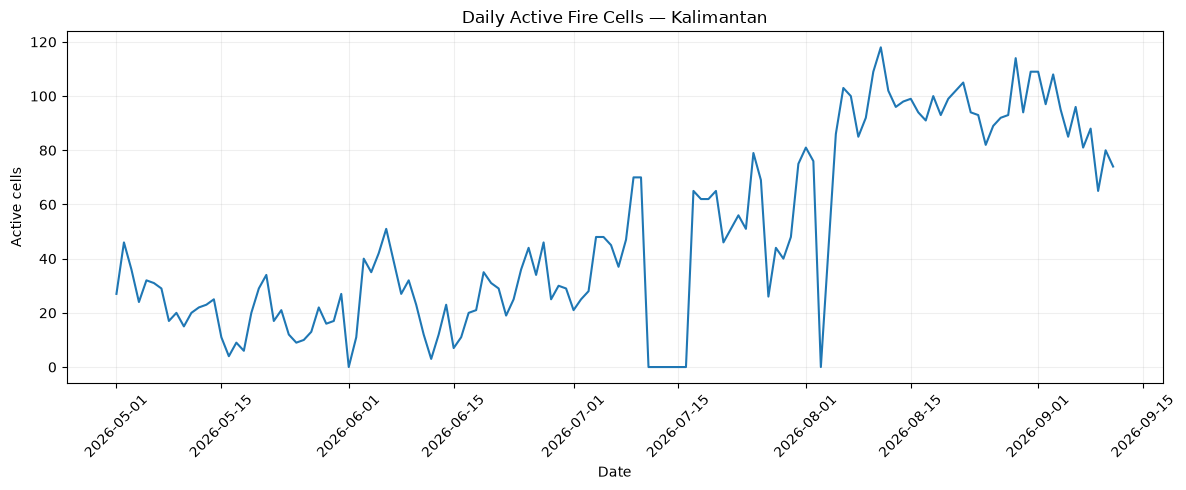

In [25]:
daily_summary = (
    panel
    .groupby("date", as_index=False)
    .agg(
        active_cells=("fire_active", "sum"),
        total_fire_detections=("fire_count", "sum"),
        total_frp=("frp_sum", "sum")
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_summary["date"],
    daily_summary["active_cells"]
)

ax.set_xlabel("Date")
ax.set_ylabel("Active cells")
ax.set_title("Daily Active Fire Cells — Kalimantan")
ax.grid(alpha=0.2)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 15. Spatial distribution of active cells

A simple grid-level visualization is used as a sanity check.


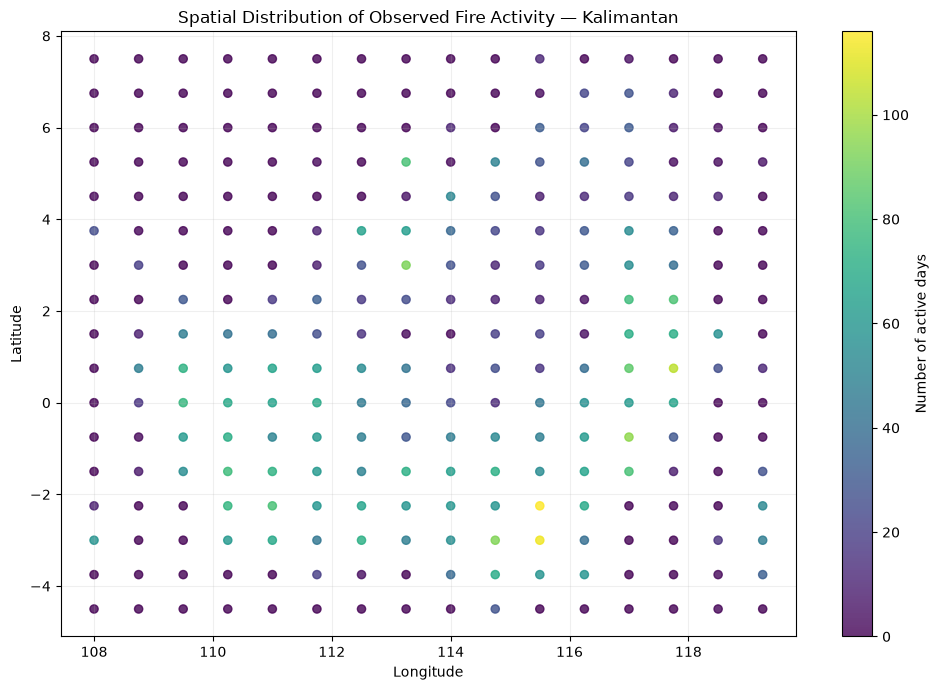

In [26]:
active_by_cell = (
    panel
    .groupby(
        ["cell_id", "grid_lat", "grid_lon"],
        as_index=False
    )
    .agg(
        active_days=("fire_active", "sum"),
        total_frp=("frp_sum", "sum")
    )
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    active_by_cell["grid_lon"],
    active_by_cell["grid_lat"],
    c=active_by_cell["active_days"],
    s=35,
    alpha=0.8
)

plt.colorbar(scatter, label="Number of active days")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Observed Fire Activity — Kalimantan")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 16. Save outputs

Two outputs are saved:

1. `fire_kalimantan_cell_day_full.csv` — complete cell × date panel.
2. `fire_kalimantan_model_panel.csv` — panel after removing the final day per cell because it has no t+1 target.

These are intermediate development outputs and can be regenerated from the raw FIRMS files.


In [27]:
panel_output = INTERMEDIATE_DIR / "fire_kalimantan_cell_day_full.csv"
model_output = INTERMEDIATE_DIR / "fire_kalimantan_model_panel.csv"

panel.to_csv(panel_output, index=False)
model_panel.to_csv(model_output, index=False)

print("Saved:")
print(panel_output)
print(model_output)


Saved:
c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\fire_kalimantan_cell_day_full.csv
c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\fire_kalimantan_model_panel.csv


# PoC / Spatial Binning Conclusion

The Kalimantan fire observations have been transformed from individual FIRMS detections into a complete spatial-temporal cell-day panel.

The resulting pipeline:

```text
FIRMS detections
      ↓
Nearest project grid cell
      ↓
Cell-day aggregation
      ↓
Complete cell × date panel
      ↓
fire_active
      ↓
target_fire_active_t1
```

The output is ready for the next development stage: **feature engineering in Notebook 04**.

> This notebook intentionally focuses on Kalimantan during the development phase. After the pipeline and modeling methodology are finalized, the same pipeline will be generalized to Kalimantan + Sumatra for the final experiment.
